<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/disath-dev/notebooks/football_qa_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Football Natural Language Question Answering Using a Convolutional Neural Network

## Notebook Overview

This notebook implements the deep-learning intent-classification component of the
Football Natural Language Question Answering system.

A one-dimensional Convolutional Neural Network (1D CNN) is trained to classify football
questions into five supported intents:

1. `match_winner`
2. `match_score`
3. `match_scorers`
4. `player_match_goal_count`
5. `player_match_scoring_minutes`

The notebook uses the finalized generated question dataset from the shared data pipeline.
Questions are converted into integer sequences and passed through an embedding layer,
one-dimensional convolutional layers, global max pooling, and dense classification
layers.

The model is evaluated using both generated questions and a manually written
out-of-template robustness set. This distinction is necessary because generated-test
performance may be high when test questions use wording patterns represented during
training.

## Connect Drive and verify GPU

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import random
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("default")

RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("GPU is available for CNN training.")
else:
    print("GPU was not detected. Recheck the Colab runtime type.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available for CNN training.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Load the Finalized Question Dataset

The CNN uses the same finalized generated question dataset as the machine-learning
notebook. The available project files are inspected first to confirm the correct
dataset path and avoid loading an earlier or incomplete version.

## Load the Version 2 Dataset Splits

The finalized Version 2 train, validation, and test files are loaded directly. These
splits were created at match level, preventing questions from the same football match
from appearing across multiple subsets.

Using the exported splits also ensures that the CNN and Logistic Regression models are
evaluated on the same data.

## Load the Dataset Splits

In [2]:
SPLIT_DIRECTORY = (
    "/content/drive/MyDrive/NLP/exports_v2/splits"
)

TRAIN_FILE_PATH = os.path.join(
    SPLIT_DIRECTORY,
    "football_qa_v2_train.csv"
)

VALIDATION_FILE_PATH = os.path.join(
    SPLIT_DIRECTORY,
    "football_qa_v2_validation.csv"
)

TEST_FILE_PATH = os.path.join(
    SPLIT_DIRECTORY,
    "football_qa_v2_test.csv"
)

for dataset_path in [
    TRAIN_FILE_PATH,
    VALIDATION_FILE_PATH,
    TEST_FILE_PATH
]:
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            f"Required dataset was not found: {dataset_path}"
        )

train_df = pd.read_csv(
    TRAIN_FILE_PATH,
    low_memory=False
)

validation_df = pd.read_csv(
    VALIDATION_FILE_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_FILE_PATH,
    low_memory=False
)

print("VERSION 2 DATASET SPLITS LOADED")
print("-" * 60)
print(f"Training rows:   {len(train_df):,}")
print(f"Validation rows: {len(validation_df):,}")
print(f"Test rows:       {len(test_df):,}")
print(f"Total rows:      {len(train_df) + len(validation_df) + len(test_df):,}")

print("\nDataset columns:")
print(train_df.columns.tolist())

display(train_df.head())

VERSION 2 DATASET SPLITS LOADED
------------------------------------------------------------
Training rows:   155,578
Validation rows: 19,223
Test rows:       19,358
Total rows:      194,159

Dataset columns:
['question_id', 'semantic_question_id', 'match_id', 'intent', 'question', 'answer', 'template_id', 'template_family', 'template_seen_in_training', 'evaluation_track', 'question_variant', 'date_format', 'team_order', 'source_dataset', 'scorer', 'team', 'player_goal_count', 'goal_count', 'scoring_minutes', 'date_standardized', 'home_team_standardized', 'away_team_standardized', 'home_score', 'away_score', 'tournament']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question_id,semantic_question_id,match_id,intent,question,answer,template_id,template_family,template_seen_in_training,evaluation_track,...,team,player_goal_count,goal_count,scoring_minutes,date_standardized,home_team_standardized,away_team_standardized,home_score,away_score,tournament
0,V2_STANDARD_WIN_00001,WIN_00001,MATCH_00001,match_winner,"Which side won on November 30, 1872, England o...",The match between Scotland and England ended i...,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1872-11-30,Scotland,England,0,0,Friendly
1,V2_STANDARD_WIN_00003,WIN_00003,MATCH_00003,match_winner,"Which side won on March 7, 1874, England or Sc...",Scotland won against England 2-1 on 1874-03-07.,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1874-03-07,Scotland,England,2,1,Friendly
2,V2_STANDARD_WIN_00004,WIN_00004,MATCH_00004,match_winner,"Which side won on 1875-03-06, England or Scotl...",The match between England and Scotland ended i...,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1875-03-06,England,Scotland,2,2,Friendly
3,V2_STANDARD_WIN_00006,WIN_00006,MATCH_00006,match_winner,"When Wales met Scotland on 25 Mar 1876, which ...",Scotland won against Wales 4-0 on 1876-03-25.,WIN_SEEN_08,secured,True,standard,...,NaN,NaN,NaN,NaN,1876-03-25,Scotland,Wales,4,0,Friendly
4,V2_STANDARD_WIN_00009,WIN_00009,MATCH_00009,match_winner,"When Scotland met England on March 2, 1878, wh...",Scotland won against England 7-2 on 1878-03-02.,WIN_SEEN_08,secured,True,standard,...,NaN,NaN,NaN,NaN,1878-03-02,Scotland,England,7,2,Friendly


## Validate the datasets

In [3]:
REQUIRED_COLUMNS = {
    "question",
    "answer",
    "intent",
    "match_id"
}

split_dataframes = {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df
}

print("DATASET VALIDATION")
print("-" * 60)

for split_name, split_df in split_dataframes.items():
    missing_columns = REQUIRED_COLUMNS.difference(
        split_df.columns
    )

    if missing_columns:
        raise ValueError(
            f"{split_name} split is missing columns: "
            f"{sorted(missing_columns)}"
        )

    print(f"\n{split_name} split")
    print(f"Rows: {len(split_df):,}")
    print(
        "Missing questions:",
        split_df["question"].isna().sum()
    )
    print(
        "Missing intents:",
        split_df["intent"].isna().sum()
    )
    print(
        "Duplicate question rows:",
        split_df.duplicated(
            subset=["question", "intent", "match_id"]
        ).sum()
    )
    print(
        "Unique matches:",
        split_df["match_id"].nunique()
    )
    print(
        "Intent classes:",
        split_df["intent"].nunique()
    )

DATASET VALIDATION
------------------------------------------------------------

Training split
Rows: 155,578
Missing questions: 0
Missing intents: 0
Duplicate question rows: 0
Unique matches: 39584
Intent classes: 5

Validation split
Rows: 19,223
Missing questions: 0
Missing intents: 0
Duplicate question rows: 0
Unique matches: 4948
Intent classes: 5

Test split
Rows: 19,358
Missing questions: 0
Missing intents: 0
Duplicate question rows: 0
Unique matches: 4949
Intent classes: 5


## Confirm no match leakage

In [4]:
train_match_ids = set(
    train_df["match_id"].dropna()
)

validation_match_ids = set(
    validation_df["match_id"].dropna()
)

test_match_ids = set(
    test_df["match_id"].dropna()
)

train_validation_overlap = (
    train_match_ids.intersection(validation_match_ids)
)

train_test_overlap = (
    train_match_ids.intersection(test_match_ids)
)

validation_test_overlap = (
    validation_match_ids.intersection(test_match_ids)
)

print("MATCH-LEVEL LEAKAGE CHECK")
print("-" * 60)
print(
    "Train-validation overlapping matches:",
    len(train_validation_overlap)
)
print(
    "Train-test overlapping matches:",
    len(train_test_overlap)
)
print(
    "Validation-test overlapping matches:",
    len(validation_test_overlap)
)

assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0

print("\nNo match-level leakage was detected.")

MATCH-LEVEL LEAKAGE CHECK
------------------------------------------------------------
Train-validation overlapping matches: 0
Train-test overlapping matches: 0
Validation-test overlapping matches: 0

No match-level leakage was detected.


## CNN-Specific Data Preparation

The exported questions have already passed through the shared data-cleaning and validation
pipeline. This section performs only the transformations required by the CNN.

The intent distribution is examined before labels are encoded and questions are converted
into integer sequences. All preprocessing objects are fitted using the training split only
to prevent information leakage.

## Inspect intent distribution

In [5]:
intent_distribution_df = pd.concat(
    [
        train_df["intent"].value_counts().rename("Training"),
        validation_df["intent"].value_counts().rename("Validation"),
        test_df["intent"].value_counts().rename("Test")
    ],
    axis=1
).fillna(0).astype(int)

intent_distribution_df["Total"] = (
    intent_distribution_df[
        ["Training", "Validation", "Test"]
    ].sum(axis=1)
)

intent_distribution_df["Training Percentage"] = (
    intent_distribution_df["Training"]
    / len(train_df)
    * 100
)

print("INTENT CLASS DISTRIBUTION")
print("-" * 70)

display(
    intent_distribution_df.style.format({
        "Training Percentage": "{:.2f}%"
    })
)

INTENT CLASS DISTRIBUTION
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Training,Validation,Test,Total,Training Percentage
intent,,,,,
match_winner,39584,4948,4949,49481,25.44%
match_score,39584,4948,4949,49481,25.44%
player_match_goal_count,32061,3894,3976,39931,20.61%
player_match_scoring_minutes,31926,3888,3944,39758,20.52%
match_scorers,12423,1545,1540,15508,7.99%


## Visualize training distribution

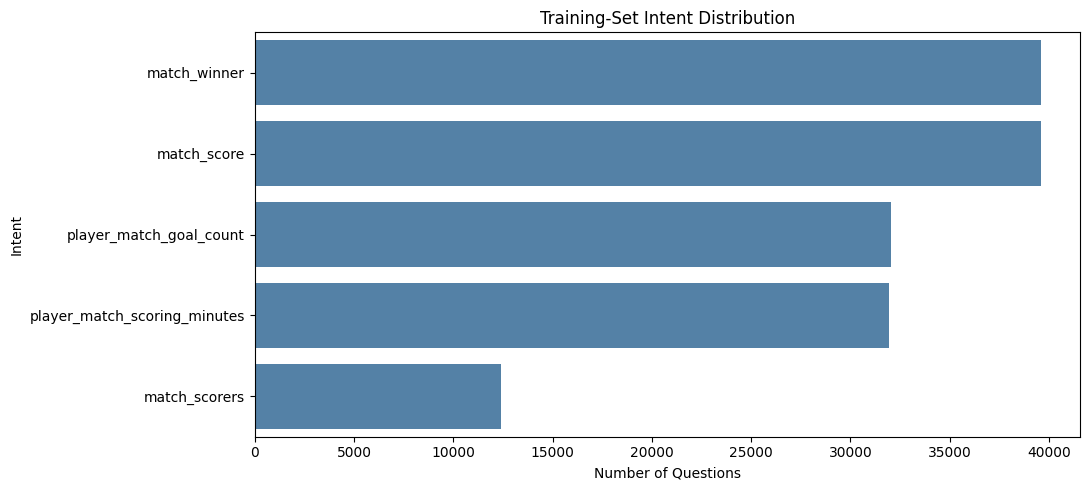

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
plt.figure(figsize=(11, 5))

sns.countplot(
    data=train_df,
    y="intent",
    order=train_df["intent"].value_counts().index,
    color="steelblue"
)

plt.title("Training-Set Intent Distribution")
plt.xlabel("Number of Questions")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

### Text Preparation Strategy

Only minimal text normalization is applied because the CNN can learn useful local patterns
from word order and neighbouring terms.

The preparation process:

1. converts questions to strings;
2. removes unnecessary leading and trailing whitespace;
3. replaces repeated whitespace with a single space; and
4. preserves meaningful words and sentence structure.

Stop-word removal and stemming are not applied because terms such as “who,” “when,” “how
many,” and “between” help distinguish the supported football-question intents.

## Prepare question text

In [7]:
def prepare_cnn_text(text):
    """
    Apply minimal normalization for CNN sequence modelling.
    """
    if pd.isna(text):
        return ""

    normalized_text = str(text).strip()

    normalized_text = " ".join(
        normalized_text.split()
    )

    return normalized_text


for split_name, split_df in split_dataframes.items():
    split_df["cnn_question"] = (
        split_df["question"]
        .apply(prepare_cnn_text)
    )

    empty_question_count = (
        split_df["cnn_question"]
        .eq("")
        .sum()
    )

    if empty_question_count > 0:
        raise ValueError(
            f"{split_name} split contains "
            f"{empty_question_count} empty CNN questions."
        )


print("CNN TEXT PREPARATION COMPLETE")
print("-" * 60)

for split_name, split_df in split_dataframes.items():
    print(
        f"{split_name}: "
        f"{len(split_df):,} questions, "
        f"{split_df['cnn_question'].nunique():,} unique texts"
    )

print("\nSample prepared questions:")

display(
    train_df[
        ["question", "cnn_question", "intent"]
    ].head()
)

CNN TEXT PREPARATION COMPLETE
------------------------------------------------------------
Training: 155,578 questions, 155,578 unique texts
Validation: 19,223 questions, 19,223 unique texts
Test: 19,358 questions, 19,358 unique texts

Sample prepared questions:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,cnn_question,intent
0,"Which side won on November 30, 1872, England o...","Which side won on November 30, 1872, England o...",match_winner
1,"Which side won on March 7, 1874, England or Sc...","Which side won on March 7, 1874, England or Sc...",match_winner
2,"Which side won on 1875-03-06, England or Scotl...","Which side won on 1875-03-06, England or Scotl...",match_winner
3,"When Wales met Scotland on 25 Mar 1876, which ...","When Wales met Scotland on 25 Mar 1876, which ...",match_winner
4,"When Scotland met England on March 2, 1878, wh...","When Scotland met England on March 2, 1878, wh...",match_winner


## Encode Intent Labels

The five textual intent labels are converted into integer class identifiers required by
the CNN output layer. The label encoder is fitted only on the training labels. Validation
and test labels are transformed using the already fitted encoder.

## Encode labels

In [8]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df["intent"]
)

y_validation = label_encoder.transform(
    validation_df["intent"]
)

y_test = label_encoder.transform(
    test_df["intent"]
)

intent_to_label = {
    intent: int(label)
    for label, intent in enumerate(
        label_encoder.classes_
    )
}

label_to_intent = {
    int(label): intent
    for intent, label in intent_to_label.items()
}

NUMBER_OF_CLASSES = len(
    label_encoder.classes_
)

print("INTENT LABEL ENCODING")
print("-" * 60)
print("Number of classes:", NUMBER_OF_CLASSES)
print("\nIntent-to-label mapping:")

for intent, label in intent_to_label.items():
    print(f"{label}: {intent}")

print("\nEncoded label shapes:")
print("Training:  ", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:      ", y_test.shape)

assert NUMBER_OF_CLASSES == 5
assert len(y_train) == len(train_df)
assert len(y_validation) == len(validation_df)
assert len(y_test) == len(test_df)

INTENT LABEL ENCODING
------------------------------------------------------------
Number of classes: 5

Intent-to-label mapping:
0: match_score
1: match_scorers
2: match_winner
3: player_match_goal_count
4: player_match_scoring_minutes

Encoded label shapes:
Training:   (155578,)
Validation: (19223,)
Test:       (19358,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Tokenize the Questions

A word-level tokenizer is fitted exclusively on the training questions. Fitting the tokenizer
only on training data prevents vocabulary information from the validation and test sets from
leaking into model development.

An out-of-vocabulary token is included so that unseen words can still be represented when
validation, generated-test, and manual robustness questions are transformed.

## Fit the training tokenizer

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCABULARY_SIZE = 30000
OUT_OF_VOCABULARY_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_VOCABULARY_SIZE,
    oov_token=OUT_OF_VOCABULARY_TOKEN,
    lower=True
)

tokenizer.fit_on_texts(
    train_df["cnn_question"]
)

training_sequences = tokenizer.texts_to_sequences(
    train_df["cnn_question"]
)

validation_sequences = tokenizer.texts_to_sequences(
    validation_df["cnn_question"]
)

test_sequences = tokenizer.texts_to_sequences(
    test_df["cnn_question"]
)

discovered_vocabulary_size = len(
    tokenizer.word_index
)

effective_vocabulary_size = min(
    MAX_VOCABULARY_SIZE,
    discovered_vocabulary_size + 1
)

print("TOKENIZER SUMMARY")
print("-" * 60)
print(
    "Words discovered in training:",
    f"{discovered_vocabulary_size:,}"
)
print(
    "Maximum vocabulary size:",
    f"{MAX_VOCABULARY_SIZE:,}"
)
print(
    "Effective vocabulary size:",
    f"{effective_vocabulary_size:,}"
)
print(
    "OOV token index:",
    tokenizer.word_index[OUT_OF_VOCABULARY_TOKEN]
)

print("\nSequence counts:")
print("Training:  ", len(training_sequences))
print("Validation:", len(validation_sequences))
print("Test:      ", len(test_sequences))

assert len(training_sequences) == len(train_df)
assert len(validation_sequences) == len(validation_df)
assert len(test_sequences) == len(test_df)

TOKENIZER SUMMARY
------------------------------------------------------------
Words discovered in training: 22,515
Maximum vocabulary size: 30,000
Effective vocabulary size: 22,516
OOV token index: 1

Sequence counts:
Training:   155578
Validation: 19223
Test:       19358


## Analyze Sequence Lengths

Question lengths are analyzed after tokenization to select a suitable maximum sequence length.
The selected length should preserve nearly all questions without adding excessive padding,
which would increase computation without providing useful information.

## Sequence-length statistics

In [10]:
training_sequence_lengths = np.array(
    [
        len(sequence)
        for sequence in training_sequences
    ]
)

sequence_length_percentiles = np.percentile(
    training_sequence_lengths,
    [50, 75, 90, 95, 99, 99.5, 100]
)

sequence_length_summary_df = pd.DataFrame(
    {
        "Percentile": [
            "50%",
            "75%",
            "90%",
            "95%",
            "99%",
            "99.5%",
            "100%"
        ],
        "Sequence Length": (
            sequence_length_percentiles
            .round()
            .astype(int)
        )
    }
)

print("TRAINING SEQUENCE-LENGTH SUMMARY")
print("-" * 60)

print(
    pd.Series(
        training_sequence_lengths
    ).describe().round(2)
)

print("\nSelected percentiles:")
display(sequence_length_summary_df)

TRAINING SEQUENCE-LENGTH SUMMARY
------------------------------------------------------------
count    155578.00
mean         14.87
std           2.20
min          11.00
25%          13.00
50%          15.00
75%          16.00
max          25.00
dtype: float64

Selected percentiles:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Percentile,Sequence Length
0,50%,15
1,75%,16
2,90%,18
3,95%,19
4,99%,20
5,99.5%,20
6,100%,25


## Plot sequence lengths

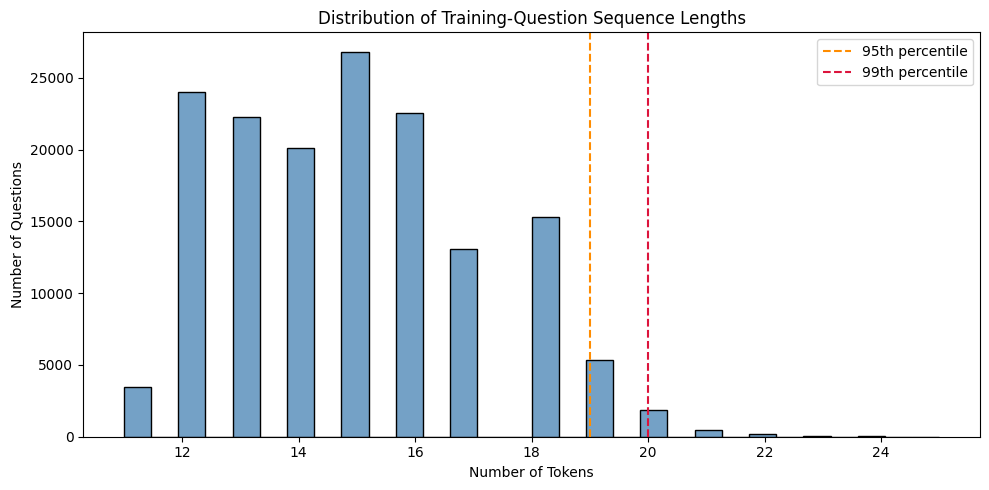

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    training_sequence_lengths,
    bins=30,
    color="steelblue"
)

plt.axvline(
    np.percentile(training_sequence_lengths, 95),
    color="darkorange",
    linestyle="--",
    label="95th percentile"
)

plt.axvline(
    np.percentile(training_sequence_lengths, 99),
    color="crimson",
    linestyle="--",
    label="99th percentile"
)

plt.title("Distribution of Training-Question Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Questions")
plt.legend()
plt.tight_layout()
plt.show()

## Measure out-of-vocabulary usage

In [12]:
OOV_TOKEN_INDEX = tokenizer.word_index[
    OUT_OF_VOCABULARY_TOKEN
]

def calculate_oov_statistics(sequences):
    total_tokens = sum(
        len(sequence)
        for sequence in sequences
    )

    oov_tokens = sum(
        token == OOV_TOKEN_INDEX
        for sequence in sequences
        for token in sequence
    )

    oov_percentage = (
        oov_tokens / total_tokens * 100
        if total_tokens > 0
        else 0.0
    )

    return total_tokens, oov_tokens, oov_percentage


print("OUT-OF-VOCABULARY ANALYSIS")
print("-" * 70)

for split_name, sequences in {
    "Training": training_sequences,
    "Validation": validation_sequences,
    "Test": test_sequences
}.items():
    total_tokens, oov_tokens, oov_percentage = (
        calculate_oov_statistics(sequences)
    )

    print(
        f"{split_name:<12} "
        f"Tokens: {total_tokens:>10,} | "
        f"OOV: {oov_tokens:>7,} | "
        f"OOV rate: {oov_percentage:.4f}%"
    )

OUT-OF-VOCABULARY ANALYSIS
----------------------------------------------------------------------
Training     Tokens:  2,313,276 | OOV:       0 | OOV rate: 0.0000%
Validation   Tokens:    285,328 | OOV:   1,873 | OOV rate: 0.6564%
Test         Tokens:    287,515 | OOV:   1,962 | OOV rate: 0.6824%


## Pad the Question Sequences

A maximum sequence length of 25 tokens is selected because it covers the longest question in
the training data. This avoids information loss from truncation while introducing only a
small amount of padding.

Zero padding is added after each question. Questions longer than 25 tokens in future or manual
inputs are also truncated from the end using the same consistent rule.

## Pad all sequences

In [13]:
MAX_SEQUENCE_LENGTH = 25

X_train = pad_sequences(
    training_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_validation = pad_sequences(
    validation_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("PADDED CNN INPUT SHAPES")
print("-" * 60)
print("Training:  ", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:      ", X_test.shape)

print("\nEncoded label shapes:")
print("Training:  ", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:      ", y_test.shape)

print("\nExample original question:")
print(train_df["cnn_question"].iloc[0])

print("\nExample token sequence:")
print(training_sequences[0])

print("\nExample padded sequence:")
print(X_train[0])

assert X_train.shape == (
    len(train_df),
    MAX_SEQUENCE_LENGTH
)

assert X_validation.shape == (
    len(validation_df),
    MAX_SEQUENCE_LENGTH
)

assert X_test.shape == (
    len(test_df),
    MAX_SEQUENCE_LENGTH
)

PADDED CNN INPUT SHAPES
------------------------------------------------------------
Training:   (155578, 25)
Validation: (19223, 25)
Test:       (19358, 25)

Encoded label shapes:
Training:   (155578,)
Validation: (19223,)
Test:       (19358,)

Example original question:
Which side won on November 30, 1872, England or Scotland, or did they draw?

Example token sequence:
[17, 27, 28, 2, 45, 139, 10720, 138, 19, 180, 19, 4, 88, 42]

Example padded sequence:
[   17    27    28     2    45   139 10720   138    19   180    19     4
    88    42     0     0     0     0     0     0     0     0     0     0
     0]


## Verify truncation and padding

In [14]:
split_sequences = {
    "Training": training_sequences,
    "Validation": validation_sequences,
    "Test": test_sequences
}

print("PADDING AND TRUNCATION CHECK")
print("-" * 60)

for split_name, sequences in split_sequences.items():
    sequence_lengths = np.array(
        [
            len(sequence)
            for sequence in sequences
        ]
    )

    truncated_count = int(
        np.sum(
            sequence_lengths
            > MAX_SEQUENCE_LENGTH
        )
    )

    padded_count = int(
        np.sum(
            sequence_lengths
            < MAX_SEQUENCE_LENGTH
        )
    )

    exact_length_count = int(
        np.sum(
            sequence_lengths
            == MAX_SEQUENCE_LENGTH
        )
    )

    print(f"\n{split_name}")
    print(
        f"Questions truncated: {truncated_count:,}"
    )
    print(
        f"Questions padded:    {padded_count:,}"
    )
    print(
        f"Exactly 25 tokens:   {exact_length_count:,}"
    )

PADDING AND TRUNCATION CHECK
------------------------------------------------------------

Training
Questions truncated: 0
Questions padded:    155,571
Exactly 25 tokens:   7

Validation
Questions truncated: 0
Questions padded:    19,223
Exactly 25 tokens:   0

Test
Questions truncated: 0
Questions padded:    19,358
Exactly 25 tokens:   0


## Handle Class Imbalance

The training distribution is moderately imbalanced, with `match_scorers` occurring less
frequently than the other intents. Balanced class weights are calculated from the training
labels so that errors involving minority classes can receive greater importance during
training.

Only the training labels are used to calculate these weights. Final per-class evaluation
metrics and the confusion matrix will be used to determine whether the CNN performs
consistently across all five intents.

## Calculate class weights

In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUMBER_OF_CLASSES),
    y=y_train
)

class_weights = {
    class_index: float(weight)
    for class_index, weight in enumerate(
        class_weight_values
    )
}

class_weight_summary_df = pd.DataFrame(
    {
        "Label": list(class_weights.keys()),
        "Intent": [
            label_to_intent[label]
            for label in class_weights.keys()
        ],
        "Training Count": [
            int(np.sum(y_train == label))
            for label in class_weights.keys()
        ],
        "Class Weight": list(class_weights.values())
    }
)

print("BALANCED TRAINING CLASS WEIGHTS")
print("-" * 60)

display(
    class_weight_summary_df.style.format({
        "Class Weight": "{:.4f}"
    })
)

assert set(class_weights.keys()) == set(
    range(NUMBER_OF_CLASSES)
)

BALANCED TRAINING CLASS WEIGHTS
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Label,Intent,Training Count,Class Weight
0,0,match_score,39584,0.7861
1,1,match_scorers,12423,2.5047
2,2,match_winner,39584,0.7861
3,3,player_match_goal_count,32061,0.9705
4,4,player_match_scoring_minutes,31926,0.9746


## Final preprocessing validation

In [16]:
print("FINAL CNN PREPROCESSING VALIDATION")
print("-" * 60)

print("Input data type:", X_train.dtype)
print("Label data type:", y_train.dtype)
print("Minimum token index:", X_train.min())
print("Maximum token index:", X_train.max())
print(
    "Effective vocabulary size:",
    effective_vocabulary_size
)
print(
    "Maximum sequence length:",
    MAX_SEQUENCE_LENGTH
)
print(
    "Number of output classes:",
    NUMBER_OF_CLASSES
)

assert X_train.min() >= 0
assert X_train.max() < effective_vocabulary_size

assert not np.isnan(X_train).any()
assert not np.isnan(X_validation).any()
assert not np.isnan(X_test).any()

assert set(np.unique(y_train)) == set(
    range(NUMBER_OF_CLASSES)
)

print("\nAll CNN inputs and labels passed validation.")

FINAL CNN PREPROCESSING VALIDATION
------------------------------------------------------------
Input data type: int32
Label data type: int64
Minimum token index: 0
Maximum token index: 22515
Effective vocabulary size: 22516
Maximum sequence length: 25
Number of output classes: 5

All CNN inputs and labels passed validation.


## Develop the One-Dimensional CNN

The intent classifier uses a one-dimensional Convolutional Neural Network designed for short
text sequences.

The architecture contains:

1. an embedding layer that learns dense word representations;
2. spatial dropout for embedding regularization;
3. a one-dimensional convolutional layer that detects informative local word patterns;
4. global max pooling that retains the strongest learned feature from each filter;
5. a dense hidden layer;
6. dropout to reduce overfitting; and
7. a softmax output layer for the five intent classes.

Sparse categorical cross-entropy is used because the intent labels are represented as integer
class identifiers.

## Build the CNN

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

EMBEDDING_DIMENSION = 128
NUMBER_OF_FILTERS = 128
KERNEL_SIZE = 3
DENSE_UNITS = 64
DROPOUT_RATE = 0.40

cnn_model = Sequential(
    [
        Input(
            shape=(MAX_SEQUENCE_LENGTH,),
            name="question_input"
        ),

        Embedding(
            input_dim=effective_vocabulary_size,
            output_dim=EMBEDDING_DIMENSION,
            name="word_embedding"
        ),

        SpatialDropout1D(
            rate=0.20,
            name="embedding_dropout"
        ),

        Conv1D(
            filters=NUMBER_OF_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation="relu",
            padding="same",
            name="text_convolution"
        ),

        GlobalMaxPooling1D(
            name="global_max_pooling"
        ),

        Dense(
            units=DENSE_UNITS,
            activation="relu",
            name="dense_hidden"
        ),

        Dropout(
            rate=DROPOUT_RATE,
            name="dense_dropout"
        ),

        Dense(
            units=NUMBER_OF_CLASSES,
            activation="softmax",
            name="intent_output"
        )
    ],
    name="football_intent_cnn"
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "football_intent_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 25, 128)        │     2,882,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, 25, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_convolution (Conv1D)       │ (None, 25, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ intent_output (Dense)           │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,939,909 (11.21 MB)

 Trainable params: 2,939,909 (11.21 MB)

 Non-trainable params: 0 (0.00 B)

## Validate the model output

In [18]:
sample_output = cnn_model(
    X_train[:4],
    training=False
)

print("CNN OUTPUT VALIDATION")
print("-" * 60)
print("Sample output shape:", sample_output.shape)
print(
    "Probability sums:",
    sample_output.numpy().sum(axis=1)
)

assert sample_output.shape == (
    4,
    NUMBER_OF_CLASSES
)

assert np.allclose(
    sample_output.numpy().sum(axis=1),
    1.0,
    atol=1e-5
)

print("\nThe CNN output layer is configured correctly.")

CNN OUTPUT VALIDATION
------------------------------------------------------------
Sample output shape: (4, 5)
Probability sums: [1. 1. 1. 1.]

The CNN output layer is configured correctly.


## Train the CNN

The CNN is trained using the training split and monitored against the validation split.

Balanced class weights are applied to reduce bias toward the more frequent intents. Early
stopping monitors validation loss and restores the weights from the best epoch. Learning-rate
reduction lowers the optimization rate if validation improvement stalls.

The generated test split and manual robustness questions remain excluded from model training
and selection.

## Configure training callbacks

In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

MODEL_DIRECTORY = (
    "/content/drive/MyDrive/NLP/models"
)

os.makedirs(
    MODEL_DIRECTORY,
    exist_ok=True
)

BEST_CNN_MODEL_PATH = os.path.join(
    MODEL_DIRECTORY,
    "disa_best_cnn_intent_model.keras"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=BEST_CNN_MODEL_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

training_callbacks = [
    early_stopping,
    reduce_learning_rate,
    model_checkpoint
]

print("TRAINING CONFIGURATION")
print("-" * 60)
print("Maximum epochs:", 15)
print("Batch size:", 256)
print("Initial learning rate:", 0.001)
print("Early-stopping patience:", 3)
print("Best-model path:", BEST_CNN_MODEL_PATH)

TRAINING CONFIGURATION
------------------------------------------------------------
Maximum epochs: 15
Batch size: 256
Initial learning rate: 0.001
Early-stopping patience: 3
Best-model path: /content/drive/MyDrive/NLP/models/disa_best_cnn_intent_model.keras


In [20]:
MAXIMUM_EPOCHS = 15
BATCH_SIZE = 256

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=MAXIMUM_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=training_callbacks,
    verbose=1
)

Epoch 1/15
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9264 - loss: 0.2911
Epoch 1: val_loss improved from None to 0.00000, saving model to /content/drive/MyDrive/NLP/models/disa_best_cnn_intent_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/disa_best_cnn_intent_model.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9835 - loss: 0.0751 - val_accuracy: 1.0000 - val_loss: 1.4677e-06 - learning_rate: 0.0010
Epoch 2/15
604/608 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.3692e-04
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_loss improved from 0.00000 to 0.00000, saving model to /content/drive/MyDrive/NLP/models/disa_best_cnn_intent_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP/models/disa_best_cnn_intent_model.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 2.6990e-04 - val_accuracy: 1.0000 - val_loss: 7.6699e-08 - le

## Summarize training

In [21]:
training_history_df = pd.DataFrame(
    cnn_history.history
)

training_history_df.index = (
    training_history_df.index + 1
)

training_history_df.index.name = "Epoch"

best_epoch = int(
    training_history_df["val_loss"].idxmin()
)

print("CNN TRAINING SUMMARY")
print("-" * 60)
print(
    "Epochs completed:",
    len(training_history_df)
)
print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    f"{training_history_df.loc[best_epoch, 'val_loss']:.4f}"
)
print(
    "Validation accuracy at best epoch:",
    f"{training_history_df.loc[best_epoch, 'val_accuracy']:.4f}"
)

display(
    training_history_df.round(4)
)

CNN TRAINING SUMMARY
------------------------------------------------------------
Epochs completed: 14
Best epoch: 11
Best validation loss: 0.0000
Validation accuracy at best epoch: 1.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,accuracy,loss,val_accuracy,val_loss,learning_rate
Epoch,,,,,
1,0.9835,0.0751,1.0,0.0,0.0010
2,1.0000,0.0003,1.0,0.0,0.0010
3,1.0000,0.0001,1.0,0.0,0.0005
4,1.0000,0.0001,1.0,0.0,0.0003
5,1.0000,0.0001,1.0,0.0,0.0001
6,1.0000,0.0001,1.0,0.0,0.0001
7,1.0000,0.0001,1.0,0.0,0.0000
8,1.0000,0.0001,1.0,0.0,0.0000
9,1.0000,0.0000,1.0,0.0,0.0000


## Inspect CNN Learning Curves

Training and validation accuracy and loss are plotted across epochs. Because validation loss
became extremely small, a logarithmic scale is used for the loss graph so that changes remain
visible.

Perfect performance on generated validation questions should be interpreted cautiously. The
dataset uses controlled intent-specific templates, so strong performance may reflect effective
recognition of those wording patterns rather than complete generalization to naturally written
questions.

## Plot Learning Curves

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

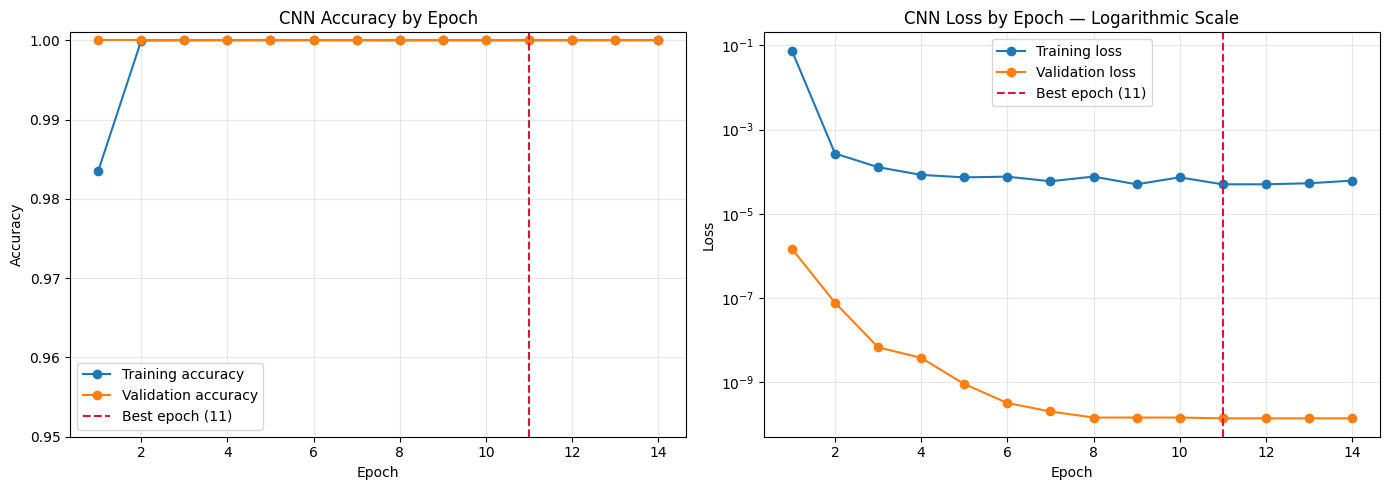

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

epochs_completed = training_history_df.index

axes[0].plot(
    epochs_completed,
    training_history_df["accuracy"],
    marker="o",
    label="Training accuracy"
)

axes[0].plot(
    epochs_completed,
    training_history_df["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[0].axvline(
    best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch ({best_epoch})"
)

axes[0].set_title("CNN Accuracy by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.95, 1.001)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs_completed,
    training_history_df["loss"],
    marker="o",
    label="Training loss"
)

axes[1].plot(
    epochs_completed,
    training_history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[1].axvline(
    best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch ({best_epoch})"
)

axes[1].set_yscale("log")
axes[1].set_title("CNN Loss by Epoch — Logarithmic Scale")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Verify the saved best model

In [23]:
best_cnn_model = tf.keras.models.load_model(
    BEST_CNN_MODEL_PATH
)

restored_validation_loss, restored_validation_accuracy = (
    best_cnn_model.evaluate(
        X_validation,
        y_validation,
        batch_size=512,
        verbose=0
    )
)

print("RESTORED BEST-MODEL VALIDATION")
print("-" * 60)
print(
    "Validation loss:",
    f"{restored_validation_loss:.12e}"
)
print(
    "Validation accuracy:",
    f"{restored_validation_accuracy:.4f}"
)
print(
    "Saved model exists:",
    os.path.exists(BEST_CNN_MODEL_PATH)
)

assert np.isclose(
    restored_validation_accuracy,
    training_history_df.loc[
        best_epoch,
        "val_accuracy"
    ],
    atol=1e-6
)

print("\nThe saved Epoch-8 model was loaded successfully.")

RESTORED BEST-MODEL VALIDATION
------------------------------------------------------------
Validation loss: 1.364305335372e-10
Validation accuracy: 1.0000
Saved model exists: True

The saved Epoch-8 model was loaded successfully.


## Generated-Test Evaluation

The best CNN checkpoint is evaluated on the generated test split. These questions come from
matches excluded from training and validation, which prevents match-level leakage.

However, their language still follows the controlled generation system. Therefore, this
evaluation measures generalization to unseen matches under generated wording, while the later
manual evaluation measures robustness to independently written language.

## Generate test predictions

In [24]:
test_probability_matrix = best_cnn_model.predict(
    X_test,
    batch_size=512,
    verbose=1
)

test_predicted_labels = np.argmax(
    test_probability_matrix,
    axis=1
)

test_predicted_intents = label_encoder.inverse_transform(
    test_predicted_labels
)

test_prediction_confidence = np.max(
    test_probability_matrix,
    axis=1
)

test_results_df = (
    test_df[
        [
            "question_id",
            "match_id",
            "question",
            "intent"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

test_results_df["predicted_intent"] = (
    test_predicted_intents
)

test_results_df["prediction_confidence"] = (
    test_prediction_confidence
)

test_results_df["correct"] = (
    test_results_df["intent"]
    == test_results_df["predicted_intent"]
)

print("GENERATED-TEST PREDICTIONS COMPLETE")
print("-" * 60)
print("Prediction matrix:", test_probability_matrix.shape)
print("Result rows:", len(test_results_df))

display(test_results_df.head())

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
GENERATED-TEST PREDICTIONS COMPLETE
------------------------------------------------------------
Prediction matrix: (19358, 5)
Result rows: 19358


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question_id,match_id,question,intent,predicted_intent,prediction_confidence,correct
0,V2_STANDARD_WIN_00002,MATCH_00002,How did the match between England and Scotland...,match_winner,match_winner,1.0,True
1,V2_STANDARD_WIN_00008,MATCH_00008,"Which side won on 5 Mar 1877, Wales or Scotlan...",match_winner,match_winner,1.0,True
2,V2_STANDARD_WIN_00063,MATCH_00063,How did the match between Wales and England fi...,match_winner,match_winner,1.0,True
3,V2_STANDARD_WIN_00072,MATCH_00072,"Who won, or was it a draw, when Wales played S...",match_winner,match_winner,1.0,True
4,V2_STANDARD_WIN_00081,MATCH_00081,"Which side won on February 27, 1892, Wales or ...",match_winner,match_winner,1.0,True


## Calculate generated-test metrics

In [25]:
test_accuracy = accuracy_score(
    y_test,
    test_predicted_labels
)

test_macro_precision = precision_score(
    y_test,
    test_predicted_labels,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test,
    test_predicted_labels,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    test_predicted_labels,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test,
    test_predicted_labels,
    average="weighted",
    zero_division=0
)

print("CNN GENERATED-TEST RESULTS")
print("-" * 60)
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro precision: {test_macro_precision:.4f}")
print(f"Macro recall:    {test_macro_recall:.4f}")
print(f"Macro F1-score:  {test_macro_f1:.4f}")
print(f"Weighted F1:     {test_weighted_f1:.4f}")

print("\nClassification report:\n")

print(
    classification_report(
        y_test,
        test_predicted_labels,
        labels=np.arange(NUMBER_OF_CLASSES),
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

CNN GENERATED-TEST RESULTS
------------------------------------------------------------
Accuracy:        1.0000
Macro precision: 1.0000
Macro recall:    1.0000
Macro F1-score:  1.0000
Weighted F1:     1.0000

Classification report:

                              precision    recall  f1-score   support

                 match_score     1.0000    1.0000    1.0000      4949
               match_scorers     1.0000    1.0000    1.0000      1540
                match_winner     1.0000    1.0000    1.0000      4949
     player_match_goal_count     1.0000    1.0000    1.0000      3976
player_match_scoring_minutes     1.0000    1.0000    1.0000      3944

                    accuracy                         1.0000     19358
                   macro avg     1.0000    1.0000    1.0000     19358
                weighted avg     1.0000    1.0000    1.0000     19358



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Plot generated-test confusion matrix

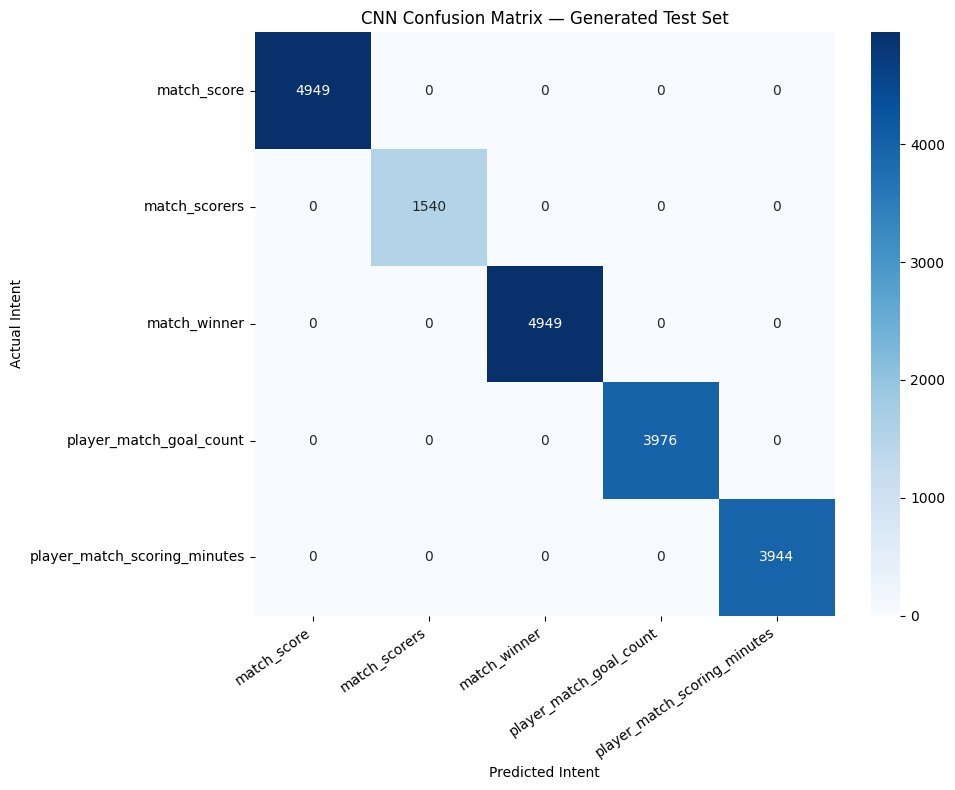

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
generated_test_confusion_matrix = confusion_matrix(
    y_test,
    test_predicted_labels,
    labels=np.arange(NUMBER_OF_CLASSES)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    generated_test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("CNN Confusion Matrix — Generated Test Set")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Inspect errors and confidence

In [27]:
generated_test_errors_df = (
    test_results_df.loc[
        ~test_results_df["correct"]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

print("GENERATED-TEST ERROR AND CONFIDENCE ANALYSIS")
print("-" * 60)
print(
    "Correct predictions:",
    f"{test_results_df['correct'].sum():,}"
)
print(
    "Incorrect predictions:",
    f"{len(generated_test_errors_df):,}"
)
print(
    "Mean confidence:",
    f"{test_results_df['prediction_confidence'].mean():.4f}"
)

print("\nConfidence summary:")
print(
    test_results_df["prediction_confidence"]
    .describe()
    .round(4)
)

if len(generated_test_errors_df) > 0:
    print("\nHighest-confidence errors:")

    display(
        generated_test_errors_df[
            [
                "question",
                "intent",
                "predicted_intent",
                "prediction_confidence"
            ]
        ].head(15)
    )
else:
    print(
        "\nNo generated-test errors were found. "
        "The manual robustness evaluation remains necessary."
    )

print("\nLowest-confidence generated-test predictions:")

display(
    test_results_df.sort_values(
        "prediction_confidence"
    )[
        [
            "question",
            "intent",
            "predicted_intent",
            "prediction_confidence"
        ]
    ].head(15)
)

GENERATED-TEST ERROR AND CONFIDENCE ANALYSIS
------------------------------------------------------------
Correct predictions: 19,358
Incorrect predictions: 0
Mean confidence: 1.0000

Confidence summary:
count    19358.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: prediction_confidence, dtype: float64

No generated-test errors were found. The manual robustness evaluation remains necessary.

Lowest-confidence generated-test predictions:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,intent,predicted_intent,prediction_confidence
16561,When did Choi Won-nam score in the match betwe...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
18865,When did Sergej Milinković-Savić score in the ...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
18373,When did Shane Long score in the match between...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
18691,When did Haris Seferovic score in the match be...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
17982,When did Hwang Jae-won score in the match betw...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
16955,When did Robbie Keane score in the match betwe...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
16402,When did Paul McGrath score in the match betwe...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
16030,When did Oleg Blokhin score in the match betwe...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
15704,When did David Herd score in the match between...,player_match_scoring_minutes,player_match_scoring_minutes,1.0
15518,When did Jimmy Dunne score in the match betwee...,player_match_scoring_minutes,player_match_scoring_minutes,1.0


## Create the complete manual robustness set

In [28]:
manual_robustness_data = [
    # match_winner
    ("Which country came out on top in the Brazil Germany game?",
     "match_winner"),
    ("Between France and Argentina, who took the win?",
     "match_winner"),
    ("Tell me which side defeated the other when Spain faced Italy.",
     "match_winner"),
    ("Was Portugal or Netherlands the victorious team?",
     "match_winner"),
    ("Who walked away with the victory from England against Croatia?",
     "match_winner"),
    ("Which team got the better of Belgium in their game with Japan?",
     "match_winner"),
    ("Did Uruguay beat Ghana, or did Ghana beat Uruguay?",
     "match_winner"),
    ("Who ended up winning Morocco versus Canada?",
     "match_winner"),
    ("Which side was the winner of the Germany Argentina fixture?",
     "match_winner"),
    ("Who won btween Brazil and Chile?",
     "match_winner"),

    # match_score
    ("How many did Brazil and Germany finish with?",
     "match_score"),
    ("Give me the final numbers from France versus Argentina.",
     "match_score"),
    ("What did the scoreboard show after Spain played Italy?",
     "match_score"),
    ("How did Portugal Netherlands end score-wise?",
     "match_score"),
    ("Tell me the full-time scoreline for England against Croatia.",
     "match_score"),
    ("What were the scores for Belgium and Japan?",
     "match_score"),
    ("How many goals did each side have when Uruguay met Ghana?",
     "match_score"),
    ("What was on the board at full time in Morocco versus Canada?",
     "match_score"),
    ("Germany Argentina — what did it finish?",
     "match_score"),
    ("Wht was the final scor in Brazil versus Chile?",
     "match_score"),

    # match_scorers
    ("Name everyone who found the net in Brazil against Germany.",
     "match_scorers"),
    ("Which footballers got on the scoresheet in France versus Argentina?",
     "match_scorers"),
    ("Give me the names of the goal-getters from Spain Italy.",
     "match_scorers"),
    ("Who put the ball in the net during Portugal against Netherlands?",
     "match_scorers"),
    ("List the players responsible for the goals in England Croatia.",
     "match_scorers"),
    ("Whose names appeared on the scoresheet when Belgium met Japan?",
     "match_scorers"),
    ("Can I have all the scorers from Uruguay versus Ghana?",
     "match_scorers"),
    ("Who managed to find the back of the net in Morocco Canada?",
     "match_scorers"),
    ("Name the goal scorers for Germany against Argentina.",
     "match_scorers"),
    ("Who scord in the Brazil and Chile fixture?",
     "match_scorers"),

    # player_match_goal_count
    ("How often did Lionel Messi find the net in that fixture?",
     "player_match_goal_count"),
    ("What was Cristiano Ronaldo's goal tally for the game?",
     "player_match_goal_count"),
    ("Tell me the number of goals scored by Neymar in that match.",
     "player_match_goal_count"),
    ("Did Kylian Mbappe score once, twice, or more?",
     "player_match_goal_count"),
    ("What total did Harry Kane contribute in goals?",
     "player_match_goal_count"),
    ("How many times was Mohamed Salah on the scoresheet?",
     "player_match_goal_count"),
    ("Count Robert Lewandowski's goals in that game.",
     "player_match_goal_count"),
    ("What was Luis Suarez's scoring total for the fixture?",
     "player_match_goal_count"),
    ("How many did Erling Haaland put away in the match?",
     "player_match_goal_count"),
    ("How many gols did Antoine Griezmann get?",
     "player_match_goal_count"),

    # player_match_scoring_minutes
    ("At what points in the game did Lionel Messi find the net?",
     "player_match_scoring_minutes"),
    ("Give me the timestamps of Cristiano Ronaldo's goals.",
     "player_match_scoring_minutes"),
    ("When during the match did Neymar get on the scoresheet?",
     "player_match_scoring_minutes"),
    ("In which parts of the game did Kylian Mbappe score?",
     "player_match_scoring_minutes"),
    ("Tell me exactly when Harry Kane's goals happened.",
     "player_match_scoring_minutes"),
    ("What were the goal times for Mohamed Salah?",
     "player_match_scoring_minutes"),
    ("When did Robert Lewandowski put the ball in the net?",
     "player_match_scoring_minutes"),
    ("At which minute marks did Luis Suarez score?",
     "player_match_scoring_minutes"),
    ("How far into the game was it when Erling Haaland scored?",
     "player_match_scoring_minutes"),
    ("Wht minute did Antoine Griezmann find the net?",
     "player_match_scoring_minutes")
]

manual_robustness_df = pd.DataFrame(
    manual_robustness_data,
    columns=[
        "question",
        "expected_intent"
    ]
)

# CNN-specific minimal text preparation
manual_robustness_df["cnn_question"] = (
    manual_robustness_df["question"]
    .apply(prepare_cnn_text)
)

manual_intent_distribution_df = (
    manual_robustness_df["expected_intent"]
    .value_counts()
    .reindex(label_encoder.classes_)
    .rename_axis("intent")
    .reset_index(name="question_count")
)

print("MANUAL ROBUSTNESS SET")
print("-" * 60)
print(
    "Total questions:",
    len(manual_robustness_df)
)
print(
    "Unique questions:",
    manual_robustness_df["question"].nunique()
)
print(
    "Intent classes:",
    manual_robustness_df["expected_intent"].nunique()
)

print("\nIntent distribution:")
display(manual_intent_distribution_df)

print("\nSample manual questions:")
display(
    manual_robustness_df[
        [
            "question",
            "cnn_question",
            "expected_intent"
        ]
    ].head(10)
)

assert len(manual_robustness_df) == 50
assert manual_robustness_df["question"].nunique() == 50

assert set(
    manual_robustness_df["expected_intent"]
) == set(
    label_encoder.classes_
)

assert manual_intent_distribution_df[
    "question_count"
].eq(10).all()

print("\nManual robustness dataset passed validation.")

MANUAL ROBUSTNESS SET
------------------------------------------------------------
Total questions: 50
Unique questions: 50
Intent classes: 5

Intent distribution:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,intent,question_count
0,match_score,10
1,match_scorers,10
2,match_winner,10
3,player_match_goal_count,10
4,player_match_scoring_minutes,10



Sample manual questions:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,cnn_question,expected_intent
0,Which country came out on top in the Brazil Ge...,Which country came out on top in the Brazil Ge...,match_winner
1,"Between France and Argentina, who took the win?","Between France and Argentina, who took the win?",match_winner
2,Tell me which side defeated the other when Spa...,Tell me which side defeated the other when Spa...,match_winner
3,Was Portugal or Netherlands the victorious team?,Was Portugal or Netherlands the victorious team?,match_winner
4,Who walked away with the victory from England ...,Who walked away with the victory from England ...,match_winner
5,Which team got the better of Belgium in their ...,Which team got the better of Belgium in their ...,match_winner
6,"Did Uruguay beat Ghana, or did Ghana beat Urug...","Did Uruguay beat Ghana, or did Ghana beat Urug...",match_winner
7,Who ended up winning Morocco versus Canada?,Who ended up winning Morocco versus Canada?,match_winner
8,Which side was the winner of the Germany Argen...,Which side was the winner of the Germany Argen...,match_winner
9,Who won btween Brazil and Chile?,Who won btween Brazil and Chile?,match_winner



Manual robustness dataset passed validation.


## Transform manual questions

In [29]:
manual_sequences = tokenizer.texts_to_sequences(
    manual_robustness_df["cnn_question"]
)

X_manual = pad_sequences(
    manual_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_manual = label_encoder.transform(
    manual_robustness_df["expected_intent"]
)

manual_sequence_lengths = np.array(
    [
        len(sequence)
        for sequence in manual_sequences
    ]
)

manual_total_tokens, manual_oov_tokens, manual_oov_percentage = (
    calculate_oov_statistics(manual_sequences)
)

print("MANUAL CNN INPUT PREPARATION")
print("-" * 60)
print("Input shape:", X_manual.shape)
print("Label shape:", y_manual.shape)
print(
    "Sequence-length range:",
    f"{manual_sequence_lengths.min()}–"
    f"{manual_sequence_lengths.max()}"
)
print(
    "Questions requiring truncation:",
    int(
        np.sum(
            manual_sequence_lengths
            > MAX_SEQUENCE_LENGTH
        )
    )
)
print("Total tokens:", manual_total_tokens)
print("OOV tokens:", manual_oov_tokens)
print(
    "OOV rate:",
    f"{manual_oov_percentage:.2f}%"
)

assert X_manual.shape == (
    50,
    MAX_SEQUENCE_LENGTH
)

assert len(y_manual) == 50

MANUAL CNN INPUT PREPARATION
------------------------------------------------------------
Input shape: (50, 25)
Label shape: (50,)
Sequence-length range: 6–12
Questions requiring truncation: 0
Total tokens: 464
OOV tokens: 89
OOV rate: 19.18%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Predict manual intents

In [30]:
manual_probability_matrix = best_cnn_model.predict(
    X_manual,
    batch_size=50,
    verbose=0
)

manual_predicted_labels = np.argmax(
    manual_probability_matrix,
    axis=1
)

manual_predicted_intents = label_encoder.inverse_transform(
    manual_predicted_labels
)

manual_prediction_confidence = np.max(
    manual_probability_matrix,
    axis=1
)

manual_robustness_df["predicted_intent"] = (
    manual_predicted_intents
)

manual_robustness_df["prediction_confidence"] = (
    manual_prediction_confidence
)

manual_robustness_df["correct"] = (
    manual_robustness_df["expected_intent"]
    == manual_robustness_df["predicted_intent"]
)

print("MANUAL ROBUSTNESS PREDICTIONS COMPLETE")
print("-" * 60)

display(
    manual_robustness_df[
        [
            "question",
            "expected_intent",
            "predicted_intent",
            "prediction_confidence",
            "correct"
        ]
    ]
)

MANUAL ROBUSTNESS PREDICTIONS COMPLETE
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,expected_intent,predicted_intent,prediction_confidence,correct
0,Which country came out on top in the Brazil Ge...,match_winner,match_scorers,0.998257,False
1,"Between France and Argentina, who took the win?",match_winner,match_scorers,0.840672,False
2,Tell me which side defeated the other when Spa...,match_winner,match_scorers,0.983078,False
3,Was Portugal or Netherlands the victorious team?,match_winner,match_winner,0.999989,True
4,Who walked away with the victory from England ...,match_winner,match_scorers,0.999554,False
5,Which team got the better of Belgium in their ...,match_winner,match_scorers,0.995658,False
6,"Did Uruguay beat Ghana, or did Ghana beat Urug...",match_winner,match_winner,1.000000,True
7,Who ended up winning Morocco versus Canada?,match_winner,match_scorers,0.921469,False
8,Which side was the winner of the Germany Argen...,match_winner,match_winner,0.969038,True
9,Who won btween Brazil and Chile?,match_winner,match_winner,0.987305,True


## Calculate manual metrics

In [31]:
manual_accuracy = accuracy_score(
    y_manual,
    manual_predicted_labels
)

manual_macro_precision = precision_score(
    y_manual,
    manual_predicted_labels,
    average="macro",
    zero_division=0
)

manual_macro_recall = recall_score(
    y_manual,
    manual_predicted_labels,
    average="macro",
    zero_division=0
)

manual_macro_f1 = f1_score(
    y_manual,
    manual_predicted_labels,
    average="macro",
    zero_division=0
)

manual_weighted_f1 = f1_score(
    y_manual,
    manual_predicted_labels,
    average="weighted",
    zero_division=0
)

print("CNN MANUAL ROBUSTNESS RESULTS")
print("-" * 60)
print(f"Accuracy:        {manual_accuracy:.4f}")
print(f"Macro precision: {manual_macro_precision:.4f}")
print(f"Macro recall:    {manual_macro_recall:.4f}")
print(f"Macro F1-score:  {manual_macro_f1:.4f}")
print(f"Weighted F1:     {manual_weighted_f1:.4f}")
print(
    "Mean confidence:",
    f"{manual_prediction_confidence.mean():.4f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        y_manual,
        manual_predicted_labels,
        labels=np.arange(NUMBER_OF_CLASSES),
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

CNN MANUAL ROBUSTNESS RESULTS
------------------------------------------------------------
Accuracy:        0.6600
Macro precision: 0.7133
Macro recall:    0.6600
Macro F1-score:  0.6571
Weighted F1:     0.6571
Mean confidence: 0.9392

Classification report:

                              precision    recall  f1-score   support

                 match_score     1.0000    0.5000    0.6667        10
               match_scorers     0.5000    0.9000    0.6429        10
                match_winner     0.5000    0.4000    0.4444        10
     player_match_goal_count     0.9000    0.9000    0.9000        10
player_match_scoring_minutes     0.6667    0.6000    0.6316        10

                    accuracy                         0.6600        50
                   macro avg     0.7133    0.6600    0.6571        50
                weighted avg     0.7133    0.6600    0.6571        50



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Manual confusion matrix

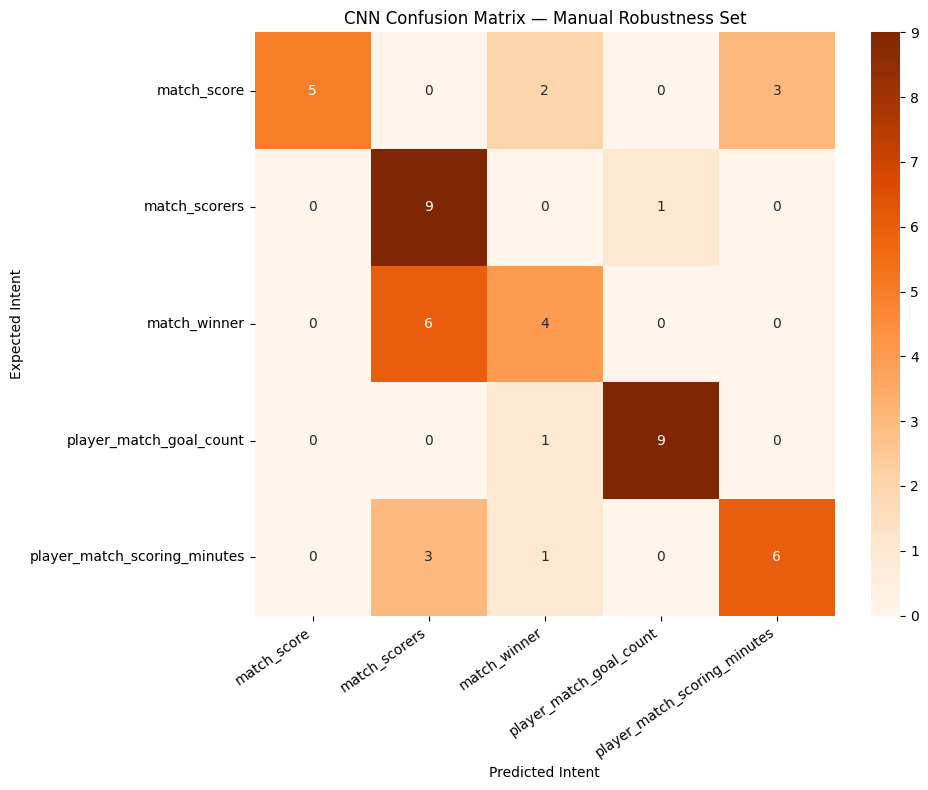

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
manual_confusion_matrix = confusion_matrix(
    y_manual,
    manual_predicted_labels,
    labels=np.arange(NUMBER_OF_CLASSES)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    manual_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("CNN Confusion Matrix — Manual Robustness Set")
plt.xlabel("Predicted Intent")
plt.ylabel("Expected Intent")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Manual Robustness Error Analysis

The CNN performs substantially worse on independently written questions than on generated
test questions. This gap indicates that the generated templates are considerably easier to
classify than natural out-of-template language.

The following analysis examines incorrect predictions, confidence levels, and the relationship
between unseen vocabulary and prediction errors. The manual set is used only for final
evaluation and error interpretation, not for additional model tuning.

## Analyze manual errors

In [33]:
manual_robustness_df["sequence_length"] = (
    manual_sequence_lengths
)

manual_robustness_df["oov_token_count"] = [
    int(
        sum(
            token == OOV_TOKEN_INDEX
            for token in sequence
        )
    )
    for sequence in manual_sequences
]

manual_errors_df = (
    manual_robustness_df.loc[
        ~manual_robustness_df["correct"]
    ]
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

print("CNN MANUAL ERROR ANALYSIS")
print("-" * 60)
print(
    "Correct predictions:",
    int(manual_robustness_df["correct"].sum())
)
print(
    "Incorrect predictions:",
    len(manual_errors_df)
)
print(
    "Error rate:",
    f"{len(manual_errors_df) / len(manual_robustness_df):.2%}"
)

print("\nIncorrect manual questions:")

display(
    manual_errors_df[
        [
            "question",
            "expected_intent",
            "predicted_intent",
            "prediction_confidence",
            "sequence_length",
            "oov_token_count"
        ]
    ].style.format({
        "prediction_confidence": "{:.4f}"
    })
)

CNN MANUAL ERROR ANALYSIS
------------------------------------------------------------
Correct predictions: 33
Incorrect predictions: 17
Error rate: 34.00%

Incorrect manual questions:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,expected_intent,predicted_intent,prediction_confidence,sequence_length,oov_token_count
0,What were the scores for Belgium and Japan?,match_score,player_match_scoring_minutes,1.0000,8,1
1,Germany Argentina — what did it finish?,match_score,match_winner,1.0000,7,1
2,"Did Kylian Mbappe score once, twice, or more?",player_match_goal_count,match_winner,0.9997,8,4
3,Who walked away with the victory from England against Croatia?,match_winner,match_scorers,0.9996,10,3
4,Which country came out on top in the Brazil Germany game?,match_winner,match_scorers,0.9983,11,3
5,Which team got the better of Belgium in their game with Japan?,match_winner,match_scorers,0.9957,12,1
6,Tell me which side defeated the other when Spain faced Italy.,match_winner,match_scorers,0.9831,11,4
7,How many did Brazil and Germany finish with?,match_score,match_winner,0.9639,8,0
8,Who ended up winning Morocco versus Canada?,match_winner,match_scorers,0.9215,7,3
9,What was on the board at full time in Morocco versus Canada?,match_score,player_match_scoring_minutes,0.8819,12,3


## Summarize confusion pairs

In [34]:
manual_confusion_pairs_df = (
    manual_errors_df.groupby(
        [
            "expected_intent",
            "predicted_intent"
        ]
    )
    .size()
    .reset_index(name="error_count")
    .sort_values(
        "error_count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("MANUAL CONFUSION PAIRS")
print("-" * 60)

display(manual_confusion_pairs_df)

MANUAL CONFUSION PAIRS
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,expected_intent,predicted_intent,error_count
0,match_winner,match_scorers,6
1,player_match_scoring_minutes,match_scorers,3
2,match_score,player_match_scoring_minutes,3
3,match_score,match_winner,2
4,match_scorers,player_match_goal_count,1
5,player_match_goal_count,match_winner,1
6,player_match_scoring_minutes,match_winner,1


## Compare correct and incorrect confidence

In [35]:
manual_confidence_comparison_df = (
    manual_robustness_df.groupby(
        "correct"
    )
    .agg(
        question_count=(
            "question",
            "count"
        ),
        mean_confidence=(
            "prediction_confidence",
            "mean"
        ),
        median_confidence=(
            "prediction_confidence",
            "median"
        ),
        mean_oov_tokens=(
            "oov_token_count",
            "mean"
        )
    )
    .rename(
        index={
            False: "Incorrect",
            True: "Correct"
        }
    )
)

print("CONFIDENCE AND OOV COMPARISON")
print("-" * 60)

display(
    manual_confidence_comparison_df.style.format({
        "mean_confidence": "{:.4f}",
        "median_confidence": "{:.4f}",
        "mean_oov_tokens": "{:.2f}"
    })
)

high_confidence_errors = manual_errors_df.loc[
    manual_errors_df["prediction_confidence"] >= 0.90
]

print(
    "\nIncorrect predictions with at least 90% confidence:",
    len(high_confidence_errors)
)

CONFIDENCE AND OOV COMPARISON
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question_count,mean_confidence,median_confidence,mean_oov_tokens
correct,,,,
Incorrect,17,0.8748,0.9215,2.24
Correct,33,0.9724,1.0000,1.55



Incorrect predictions with at least 90% confidence: 9


### Manual Evaluation Interpretation

The CNN correctly classified 33 of the 50 manually written questions, producing 66% accuracy
and a macro F1-score of 0.6571. This is substantially lower than its perfect generated-test
performance.

The most frequent error was classifying `match_winner` questions as `match_scorers`: six of
the ten winner questions received this incorrect label. The model also confused several
`match_score` questions with `player_match_scoring_minutes`.

The manual questions had a 19.18% out-of-vocabulary token rate, compared with less than 0.7%
for the generated validation and test splits. This demonstrates that the independently written
questions contain substantially different vocabulary.

The CNN's mean manual confidence remained high at 0.9394 despite making 17 errors. Therefore,
softmax confidence should not be interpreted as a reliable measure of correctness for language
that differs from the generated training templates. Overall, the CNN learned the generated
intent patterns extremely well but showed limited generalization to unfamiliar natural
wording.

## Compare ML and DL Results

The CNN is compared with the final word-and-character TF-IDF Logistic Regression model using
the same generated test split and the same 50 manually written robustness questions.

The generated-test results show how well each model handles unseen matches expressed through
controlled templates. The manual results provide the more demanding comparison of
generalization to independently written language.

## Model comparison

In [36]:
model_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Word + Character TF-IDF Logistic Regression",
            "Word-Level 1D CNN"
        ],
        "Generated-Test Accuracy": [
            1.0000,
            test_accuracy
        ],
        "Generated-Test Macro F1": [
            1.0000,
            test_macro_f1
        ],
        "Manual Accuracy": [
            0.7400,
            manual_accuracy
        ],
        "Manual Macro F1": [
            0.7381,
            manual_macro_f1
        ]
    }
)

print("ML AND DL MODEL COMPARISON")
print("-" * 70)

display(
    model_comparison_df.style.format({
        "Generated-Test Accuracy": "{:.4f}",
        "Generated-Test Macro F1": "{:.4f}",
        "Manual Accuracy": "{:.4f}",
        "Manual Macro F1": "{:.4f}"
    })
)

manual_accuracy_difference = (
    model_comparison_df.loc[
        0,
        "Manual Accuracy"
    ]
    - model_comparison_df.loc[
        1,
        "Manual Accuracy"
    ]
)

print(
    "Manual accuracy advantage of Logistic Regression:",
    f"{manual_accuracy_difference:.2%}"
)

ML AND DL MODEL COMPARISON
----------------------------------------------------------------------


,Model,Generated-Test Accuracy,Generated-Test Macro F1,Manual Accuracy,Manual Macro F1
0,Word + Character TF-IDF Logistic Regression,1.0000,1.0000,0.7400,0.7381
1,Word-Level 1D CNN,1.0000,1.0000,0.6600,0.6571


Manual accuracy advantage of Logistic Regression: 8.00%


### Model Comparison Interpretation

Both models achieved perfect generated-test accuracy because the generated questions contain
strong and consistent intent-specific wording patterns. This result should not be interpreted
as complete natural-language understanding.

On the independent manual robustness set, the word-and-character TF-IDF Logistic Regression
model achieved 74% accuracy and a macro F1-score of 0.7381. The word-level CNN achieved 66%
accuracy and a macro F1-score of 0.6571. Logistic Regression therefore achieved an eight
percentage-point advantage in manual accuracy.

The CNN's lower robustness is consistent with its 19.18% manual out-of-vocabulary rate. The
Logistic Regression model's character n-gram features can retain useful subword information
from unfamiliar words and spelling errors, whereas the CNN tokenizer maps unseen words to a
single out-of-vocabulary identifier.

These results demonstrate why evaluation on independently written questions is necessary.
Generated-test performance alone would incorrectly suggest that the two models generalize
equally well.

## Save the CNN and Preprocessing Components

Deployment requires the trained CNN together with the exact tokenizer, label encoder, maximum
sequence length, and vocabulary configuration used during development. Saving all components
ensures that future questions receive the same transformations as the training data.

## Save all CNN artifacts

In [37]:
import joblib

FINAL_CNN_MODEL_PATH = os.path.join(
    MODEL_DIRECTORY,
    "disa_cnn_intent_model.keras"
)

TOKENIZER_PATH = os.path.join(
    MODEL_DIRECTORY,
    "disa_cnn_tokenizer.pkl"
)

LABEL_ENCODER_PATH = os.path.join(
    MODEL_DIRECTORY,
    "disa_cnn_label_encoder.joblib"
)

CNN_CONFIG_PATH = os.path.join(
    MODEL_DIRECTORY,
    "disa_cnn_config.json"
)

best_cnn_model.save(
    FINAL_CNN_MODEL_PATH
)

with open(
    TOKENIZER_PATH,
    "wb"
) as tokenizer_file:
    pickle.dump(
        tokenizer,
        tokenizer_file
    )

joblib.dump(
    label_encoder,
    LABEL_ENCODER_PATH
)

cnn_configuration = {
    "max_vocabulary_size": int(
        MAX_VOCABULARY_SIZE
    ),
    "effective_vocabulary_size": int(
        effective_vocabulary_size
    ),
    "max_sequence_length": int(
        MAX_SEQUENCE_LENGTH
    ),
    "embedding_dimension": int(
        EMBEDDING_DIMENSION
    ),
    "number_of_filters": int(
        NUMBER_OF_FILTERS
    ),
    "kernel_size": int(
        KERNEL_SIZE
    ),
    "dense_units": int(
        DENSE_UNITS
    ),
    "dropout_rate": float(
        DROPOUT_RATE
    ),
    "number_of_classes": int(
        NUMBER_OF_CLASSES
    ),
    "intent_classes": (
        label_encoder.classes_.tolist()
    ),
    "random_state": int(
        RANDOM_STATE
    )
}

with open(
    CNN_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        cnn_configuration,
        configuration_file,
        indent=4
    )

saved_artifact_paths = {
    "CNN model": FINAL_CNN_MODEL_PATH,
    "Tokenizer": TOKENIZER_PATH,
    "Label encoder": LABEL_ENCODER_PATH,
    "Configuration": CNN_CONFIG_PATH
}

print("CNN ARTIFACTS SAVED")
print("-" * 70)

for artifact_name, artifact_path in saved_artifact_paths.items():
    file_size_mb = (
        os.path.getsize(artifact_path)
        / (1024 ** 2)
    )

    print(
        f"{artifact_name:<15} "
        f"{file_size_mb:>8.2f} MB  "
        f"{artifact_path}"
    )

CNN ARTIFACTS SAVED
----------------------------------------------------------------------
CNN model          33.68 MB  /content/drive/MyDrive/NLP/models/disa_cnn_intent_model.keras
Tokenizer           0.86 MB  /content/drive/MyDrive/NLP/models/disa_cnn_tokenizer.pkl
Label encoder       0.00 MB  /content/drive/MyDrive/NLP/models/disa_cnn_label_encoder.joblib
Configuration       0.00 MB  /content/drive/MyDrive/NLP/models/disa_cnn_config.json


## CNN Intent-Prediction Function

The prediction function applies the saved CNN preprocessing procedure to new questions,
generates class probabilities, and returns the predicted intent and confidence score.

Confidence represents the model's largest softmax probability. The manual evaluation showed
that high confidence does not guarantee correctness for language that differs from the
generated training templates.

## Create and test the prediction function

In [38]:
def predict_cnn_intent(questions):
    """
    Predict football-question intents using the trained CNN.

    Parameters
    ----------
    questions : str or list of str
        One question or a collection of questions.

    Returns
    -------
    pandas.DataFrame
        Questions, predicted intents and confidence scores.
    """
    if isinstance(questions, str):
        questions = [questions]

    prepared_questions = [
        prepare_cnn_text(question)
        for question in questions
    ]

    question_sequences = tokenizer.texts_to_sequences(
        prepared_questions
    )

    padded_questions = pad_sequences(
        question_sequences,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probability_matrix = best_cnn_model.predict(
        padded_questions,
        verbose=0
    )

    predicted_labels = np.argmax(
        probability_matrix,
        axis=1
    )

    predicted_intents = label_encoder.inverse_transform(
        predicted_labels
    )

    confidence_scores = np.max(
        probability_matrix,
        axis=1
    )

    return pd.DataFrame(
        {
            "question": questions,
            "predicted_intent": predicted_intents,
            "confidence": confidence_scores
        }
    )


sample_questions = [
    "Who won between Brazil and Germany?",
    "What was the final score in France versus Argentina?",
    "Who scored in the Spain and Italy match?",
    "How many goals did Lionel Messi score?",
    "At what minutes did Cristiano Ronaldo score?"
]

sample_prediction_df = predict_cnn_intent(
    sample_questions
)

print("SAMPLE CNN INTENT PREDICTIONS")
print("-" * 60)

display(
    sample_prediction_df.style.format({
        "confidence": "{:.4f}"
    })
)

SAMPLE CNN INTENT PREDICTIONS
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question,predicted_intent,confidence
0,Who won between Brazil and Germany?,match_winner,0.9815
1,What was the final score in France versus Argentina?,match_score,1.0000
2,Who scored in the Spain and Italy match?,match_scorers,1.0000
3,How many goals did Lionel Messi score?,player_match_goal_count,1.0000
4,At what minutes did Cristiano Ronaldo score?,player_match_scoring_minutes,1.0000


## Verify saved artifacts

In [39]:
with open(
    TOKENIZER_PATH,
    "rb"
) as tokenizer_file:
    reloaded_tokenizer = pickle.load(
        tokenizer_file
    )

reloaded_label_encoder = joblib.load(
    LABEL_ENCODER_PATH
)

with open(
    CNN_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as configuration_file:
    reloaded_configuration = json.load(
        configuration_file
    )

reloaded_cnn_model = tf.keras.models.load_model(
    FINAL_CNN_MODEL_PATH
)

verification_question = (
    "Who scored in the Spain and Italy match?"
)

verification_sequence = (
    reloaded_tokenizer.texts_to_sequences(
        [
            prepare_cnn_text(
                verification_question
            )
        ]
    )
)

verification_input = pad_sequences(
    verification_sequence,
    maxlen=reloaded_configuration[
        "max_sequence_length"
    ],
    padding="post",
    truncating="post"
)

verification_probabilities = (
    reloaded_cnn_model.predict(
        verification_input,
        verbose=0
    )
)

verification_label = int(
    np.argmax(
        verification_probabilities,
        axis=1
    )[0]
)

verification_intent = (
    reloaded_label_encoder.inverse_transform(
        [verification_label]
    )[0]
)

verification_confidence = float(
    verification_probabilities[
        0,
        verification_label
    ]
)

print("SAVED-ARTIFACT VERIFICATION")
print("-" * 60)
print("Question:", verification_question)
print("Predicted intent:", verification_intent)
print(
    "Confidence:",
    f"{verification_confidence:.4f}"
)
print(
    "Configured classes:",
    reloaded_configuration["intent_classes"]
)

assert verification_intent == "match_scorers"
assert reloaded_configuration[
    "max_sequence_length"
] == MAX_SEQUENCE_LENGTH

assert reloaded_configuration[
    "intent_classes"
] == label_encoder.classes_.tolist()

print("\nAll saved CNN artifacts loaded and worked correctly.")

SAVED-ARTIFACT VERIFICATION
------------------------------------------------------------
Question: Who scored in the Spain and Italy match?
Predicted intent: match_scorers
Confidence: 1.0000
Configured classes: ['match_score', 'match_scorers', 'match_winner', 'player_match_goal_count', 'player_match_scoring_minutes']

All saved CNN artifacts loaded and worked correctly.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Conclusion

This notebook developed a word-level one-dimensional Convolutional Neural Network for the
intent-classification component of the Football Natural Language Question Answering system.
The model classified questions into five intents using an embedding layer, spatial dropout,
one-dimensional convolution, global max pooling, dense classification, and softmax output.

The finalized Version 2 dataset contained 155,578 training questions, 19,223 validation
questions, and 19,358 generated test questions. Match-level separation prevented questions
from the same football match from appearing across different splits. The tokenizer was fitted
only on the training questions, and balanced class weights were applied to address the smaller
`match_scorers` class.

The CNN achieved 100% accuracy and a macro F1-score of 1.0000 on the generated test set.
However, it achieved only 66% accuracy and a macro F1-score of 0.6571 on the independent
50-question manual robustness set. The largest confusion was `match_winner` being predicted
as `match_scorers`, which occurred six times.

The manual questions produced a 19.18% out-of-vocabulary rate, compared with less than 0.7%
for the generated validation and test questions. The CNN also made nine incorrect manual
predictions with at least 90% confidence. These findings show that perfect generated-test
performance primarily reflects successful learning of controlled template patterns and does
not guarantee reliable generalization to unfamiliar natural wording.

The final word-and-character TF-IDF Logistic Regression model achieved 74% manual accuracy,
outperforming the CNN by eight percentage points. Character-level features were more robust
to unfamiliar expressions and spelling errors than the CNN's word-level tokenizer.

The trained CNN, tokenizer, label encoder, and configuration were saved successfully. Future
work could improve natural-language robustness using a separate paraphrase development set,
subword tokenization, pretrained embeddings, or a more linguistically diverse training
dataset. The existing 50-question manual set should remain untouched as an independent final
evaluation set.